---
title: Linked-Read Preprocess Summary
subtitle: A look at barcode preprocessing in raw reads
date: "2026-07-10"
edit_url: null
---
**Linked-read type**: Haplotagging (GIH)

This report describes linked-read library performance, as assessed after barcode preprocessing[^1] from the sample sequences. The values in the boxes below are averages across your samples. The reads have been modified to remove all _technical_ sequences from the R1, which includes the 4 combinatorial barcodes, the spacers between them, and the ME sequence. The data still requires thorough quality assessment, which can be achieved with e.g. [harpy qc](https://pdimens.github.io/harpy/workflows/qc/).

[^1]:
    Preprocessing ('demultiplexing') barcodes describes identifying the barcode segments and moving them into the `BX` and `VX` header tags.

In [1]:
import altair as alt
import os
import numpy as np
from pathlib import Path
import polars as pl
from harpy.report.html import StatsBox, image_viewer
from harpy.report.tables import ITable
from harpy.report.theme import palette
alt.data_transformers.enable('json')

DataTransformerRegistry.enable('json')

In [2]:
indir = "Preprocess/reports/data"
d = {}

In [3]:
# Parameters
indir = "/local/workdir/pd348/mouse/fastq/preproc/reports/data"


In [4]:
def static_kneeplot(col: pl.Series, title: str, output_path: str):
    '''Create an Altair scatterplot as a PNG and save it to disk'''
    sorted_counts = col.sort(descending=True)
    n = len(sorted_counts)

    # Log-spaced indices: dense at the knee, sparse in the long tail
    indices = np.unique(np.geomspace(1, n, num=min(5000, n)).astype(int) - 1)

    df = (
        sorted_counts
        .to_frame()
        .with_row_index(name="index")
        .filter(pl.col("index").is_in(indices.tolist()))
    )

    chart = (
        alt.Chart(df)
        .mark_point(size=4)
        .encode(
            x=alt.X("index:Q", title="Barcode"),
            y=alt.Y(f"{col.name}:Q", title="Read Count").scale(type="log"),
            color=alt.Color(f"{col.name}:Q").scale(scheme="plasma", reverse=True).legend(None),
        )
        .properties(width=650, height=300, title=title)
    )
    chart.save(output_path, format="png", ppi=200)

def get_val(x):
    '''Read line of `x` and extract the value'''
    return int(x.readline().split()[-1])

In [5]:
BX_infiles = list(Path(indir).glob("*.BXstats"))

d['Sample'] = []
d['Total Reads'] = []
d['Unique Barcodes'] = []
d['Valid Barcodes'] = []
d['Failed Barcodes'] = []
d['Corrected Barcodes'] = []
d['ME Absent'] = []

for infile in BX_infiles:
    smp = infile.stem.removesuffix('.BXstats')
    d['Sample'].append(smp)
    MEfile = os.path.join(indir, f"{smp}.MEstats")
    with open(MEfile, 'r') as f:
        total = get_val(f)
        d['Total Reads'].append(total)
        d['ME Absent'].append(round(get_val(f) / total * 100, 2))
    with open(infile, 'r') as f:
        uniq = get_val(f)
        d['Unique Barcodes'].append(uniq)
        d['Failed Barcodes'].append(round(get_val(f) / 2 / total * 100, 2))
        d['Valid Barcodes'].append(round(get_val(f) / 2 / total * 100, 2))
        d['Corrected Barcodes'].append(round(get_val(f) / 2 / total * 100, 2))

data = pl.DataFrame(d)


In [6]:
avg_valid = data["Valid Barcodes"].mean()
std_valid = data["Valid Barcodes"].std() or 0

avg_corrected = data["Corrected Barcodes"].mean()
std_corrected = data["Corrected Barcodes"].std() or 0

avg_me_discard = data["ME Absent"].mean()
std_me_discard = data["ME Absent"].std() or 0

avg_fail = data["Failed Barcodes"].mean()
std_fail = data["Failed Barcodes"].std() or 0

(
    StatsBox()
    .add(len(d['Sample']), "Samples")
    .conditional(round(avg_valid,1), "% Valid", 75, plus_minus = round(std_valid,1))
    .add(round(avg_corrected, 5), "% Corrected", round(std_corrected, 5))
    .add(round(avg_fail, 5), "% BX Undetermined", round(std_fail, 5))
    .conditional(round(avg_me_discard, 5), "% ME Discard", 20, lower_bad = False, plus_minus = round(std_me_discard, 5))
    .render()
)

In the table below, `Valid Barcodes` is the percent of read pairs with a valid barcode. The `Corrected Barcodes` is the percent of reads pairs that had at least one unidentified barcode segment that was recovered by `Pheniqs`, whereas `Failed Barcodes` had at least one failing segment that `Pheniqs` could not confidently correct. The `ME Absent` column tracks the percent of read pairs that were removed due to the ME sequence not being found.

In [7]:
ITable(data, filename = "preprocess.csv").render()

## Reads per Barcode
This is a series of kneeplots, one for each sample. The plot shows the number of reads per individual unique _valid_ barcode, sorted from highest to lowest.


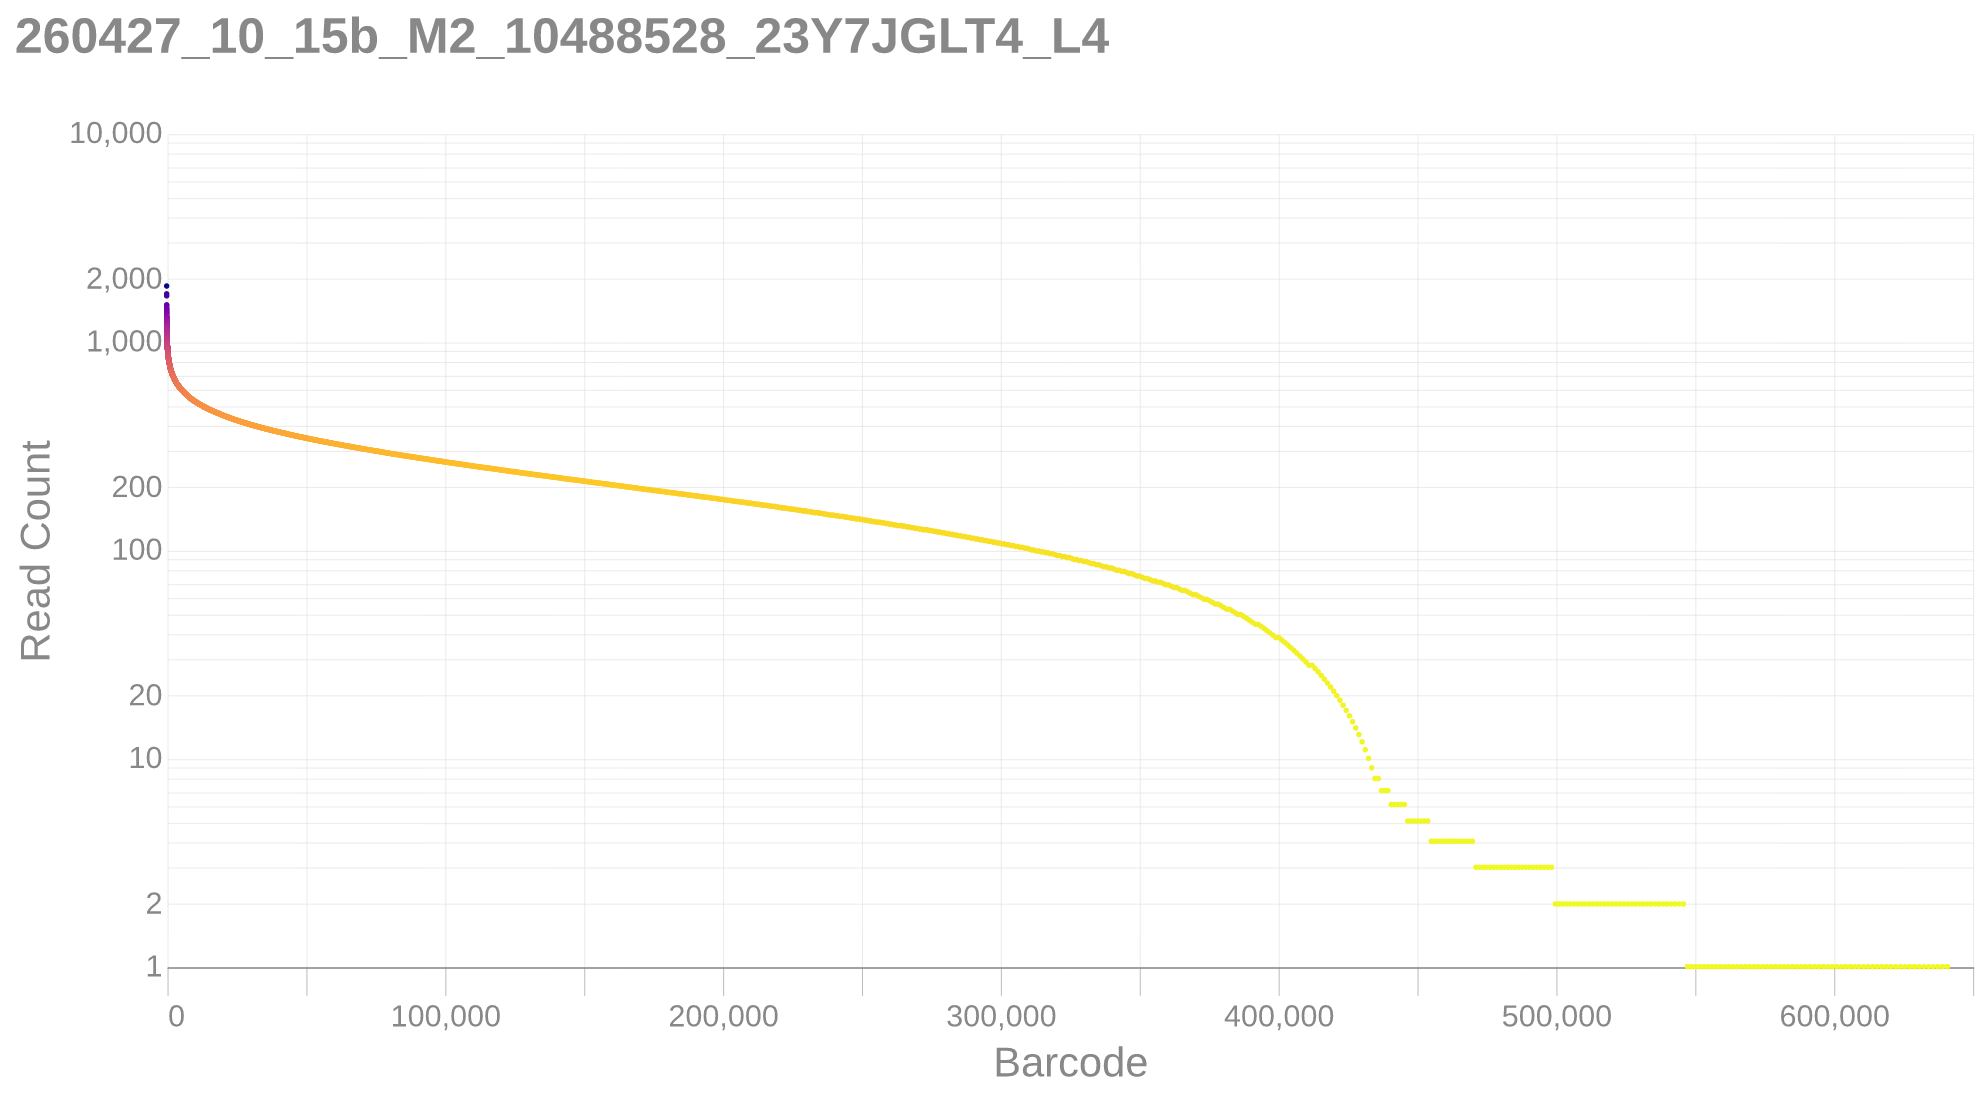
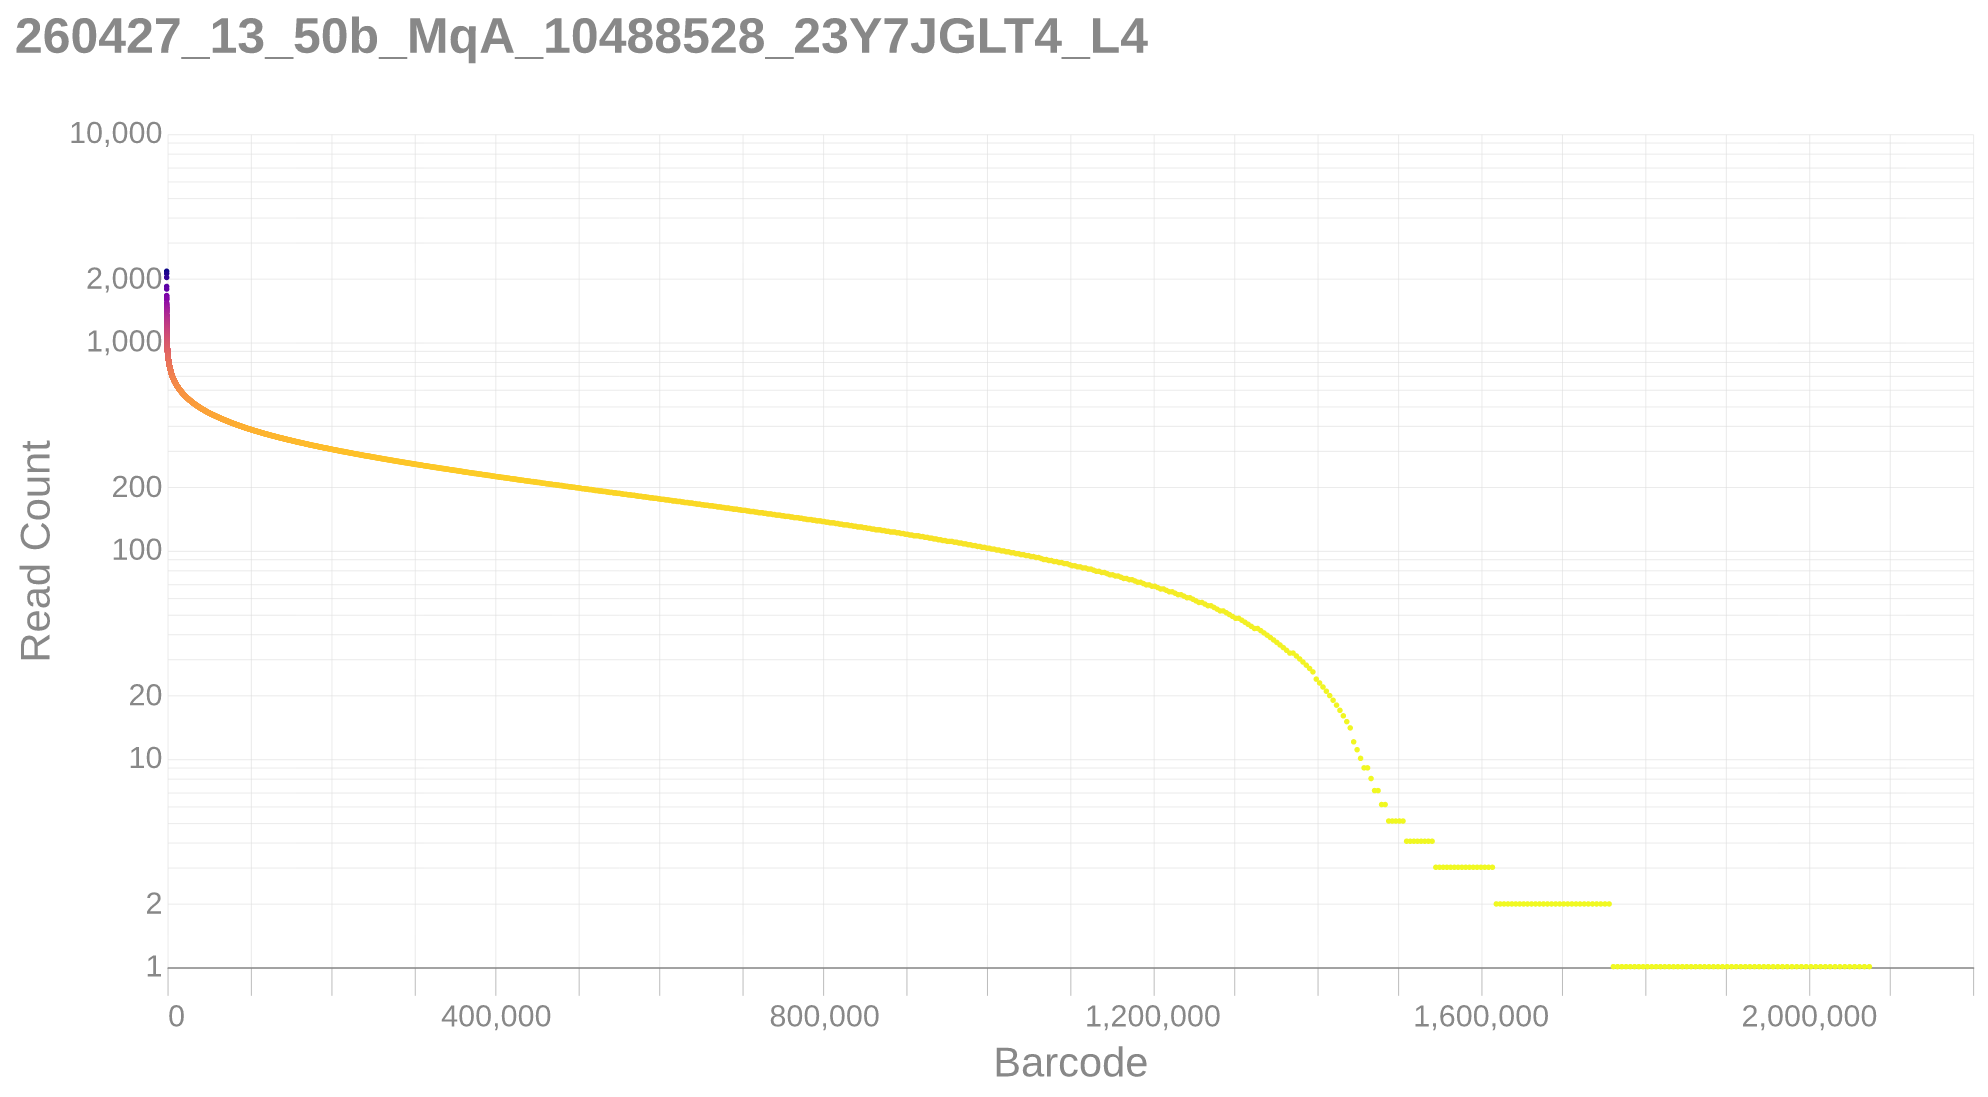
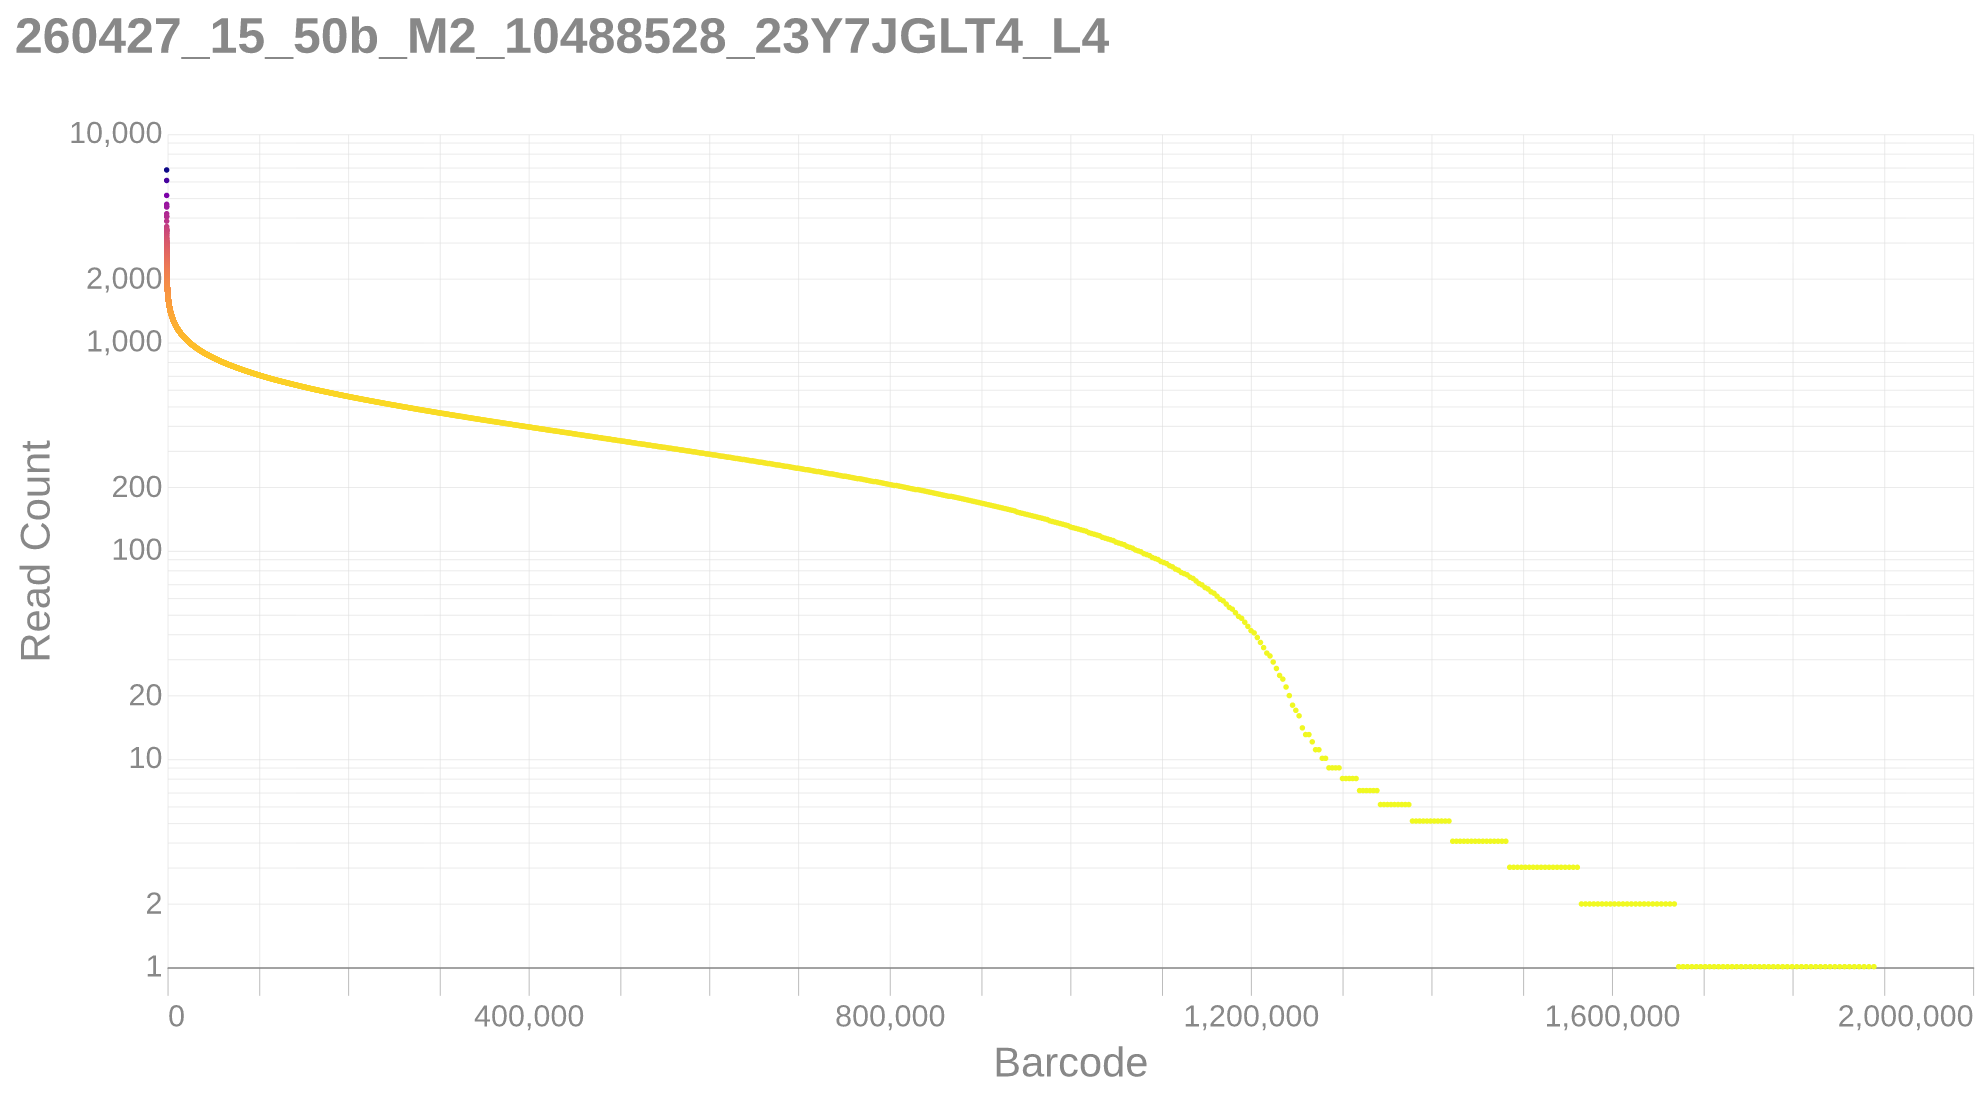
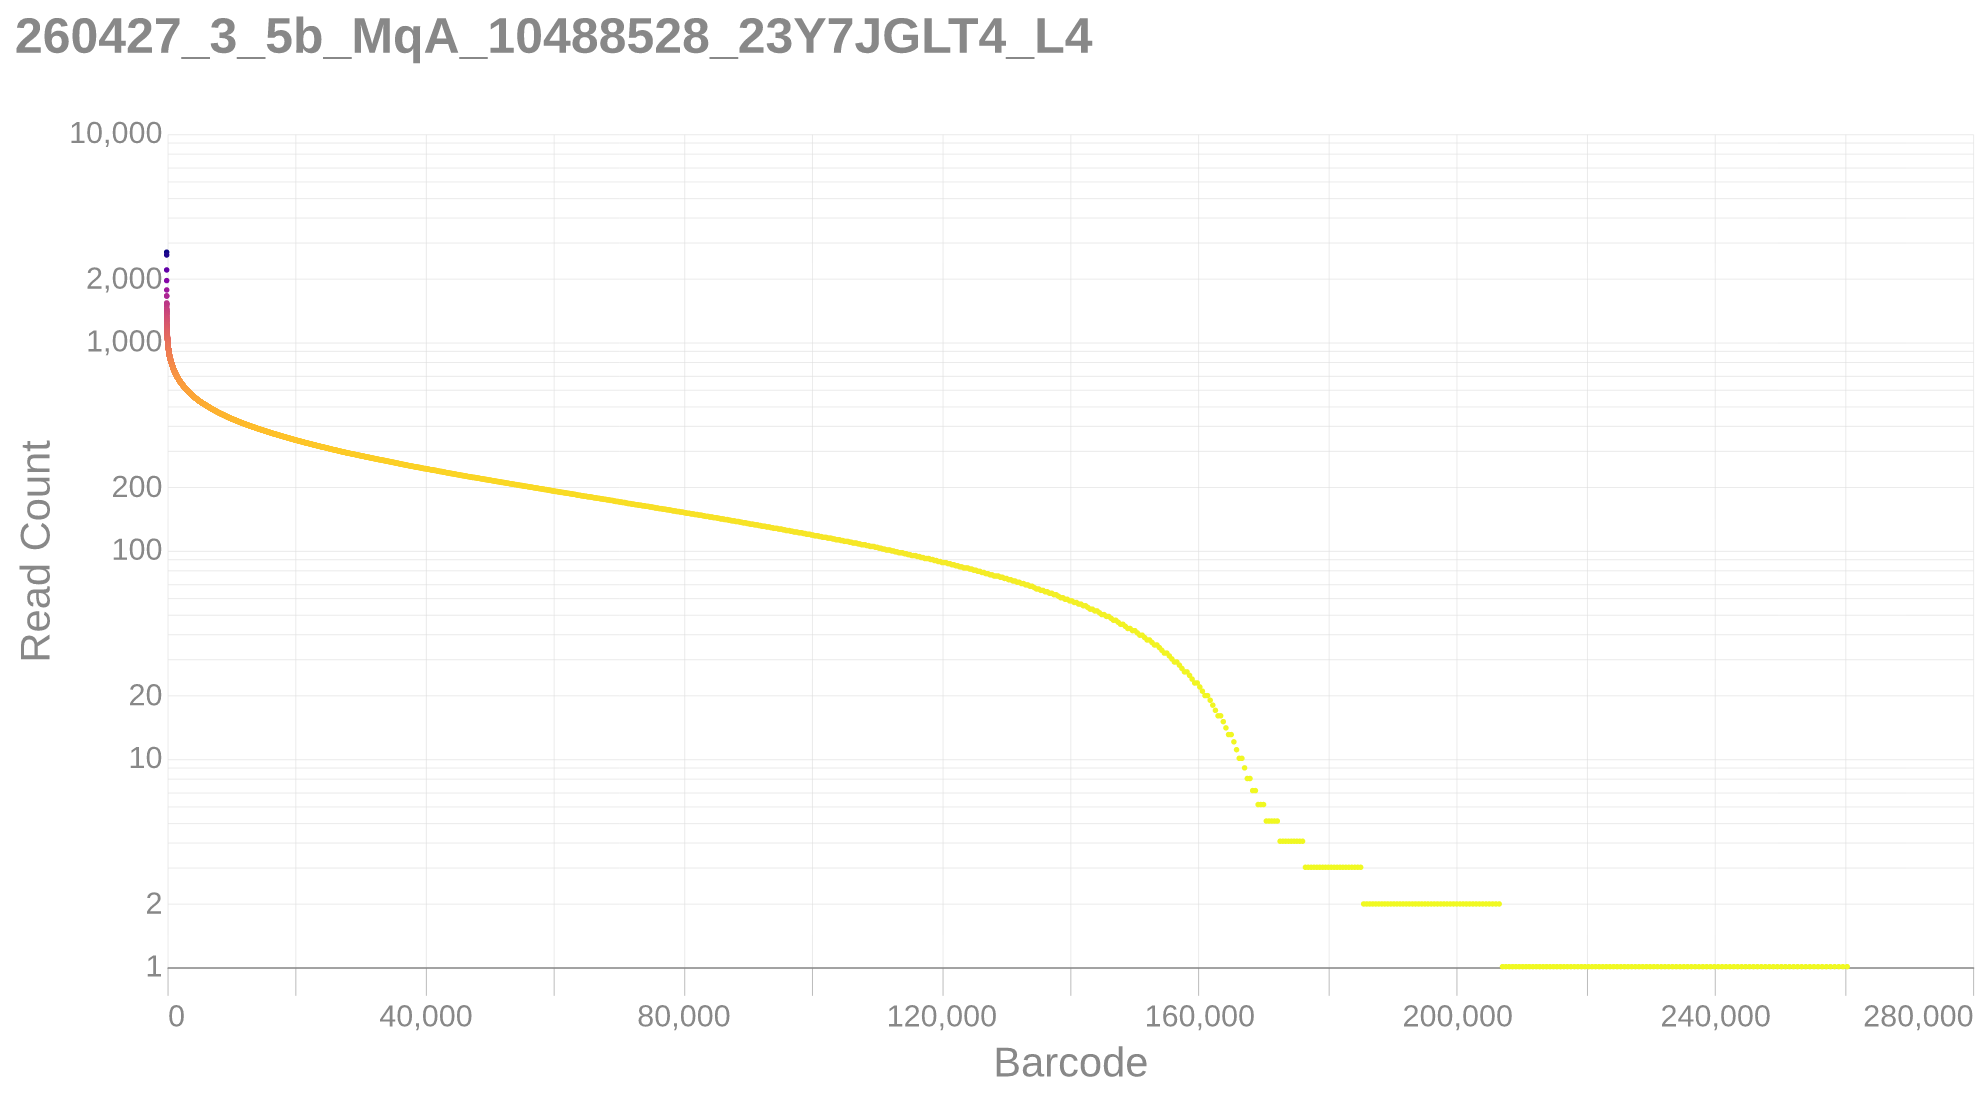
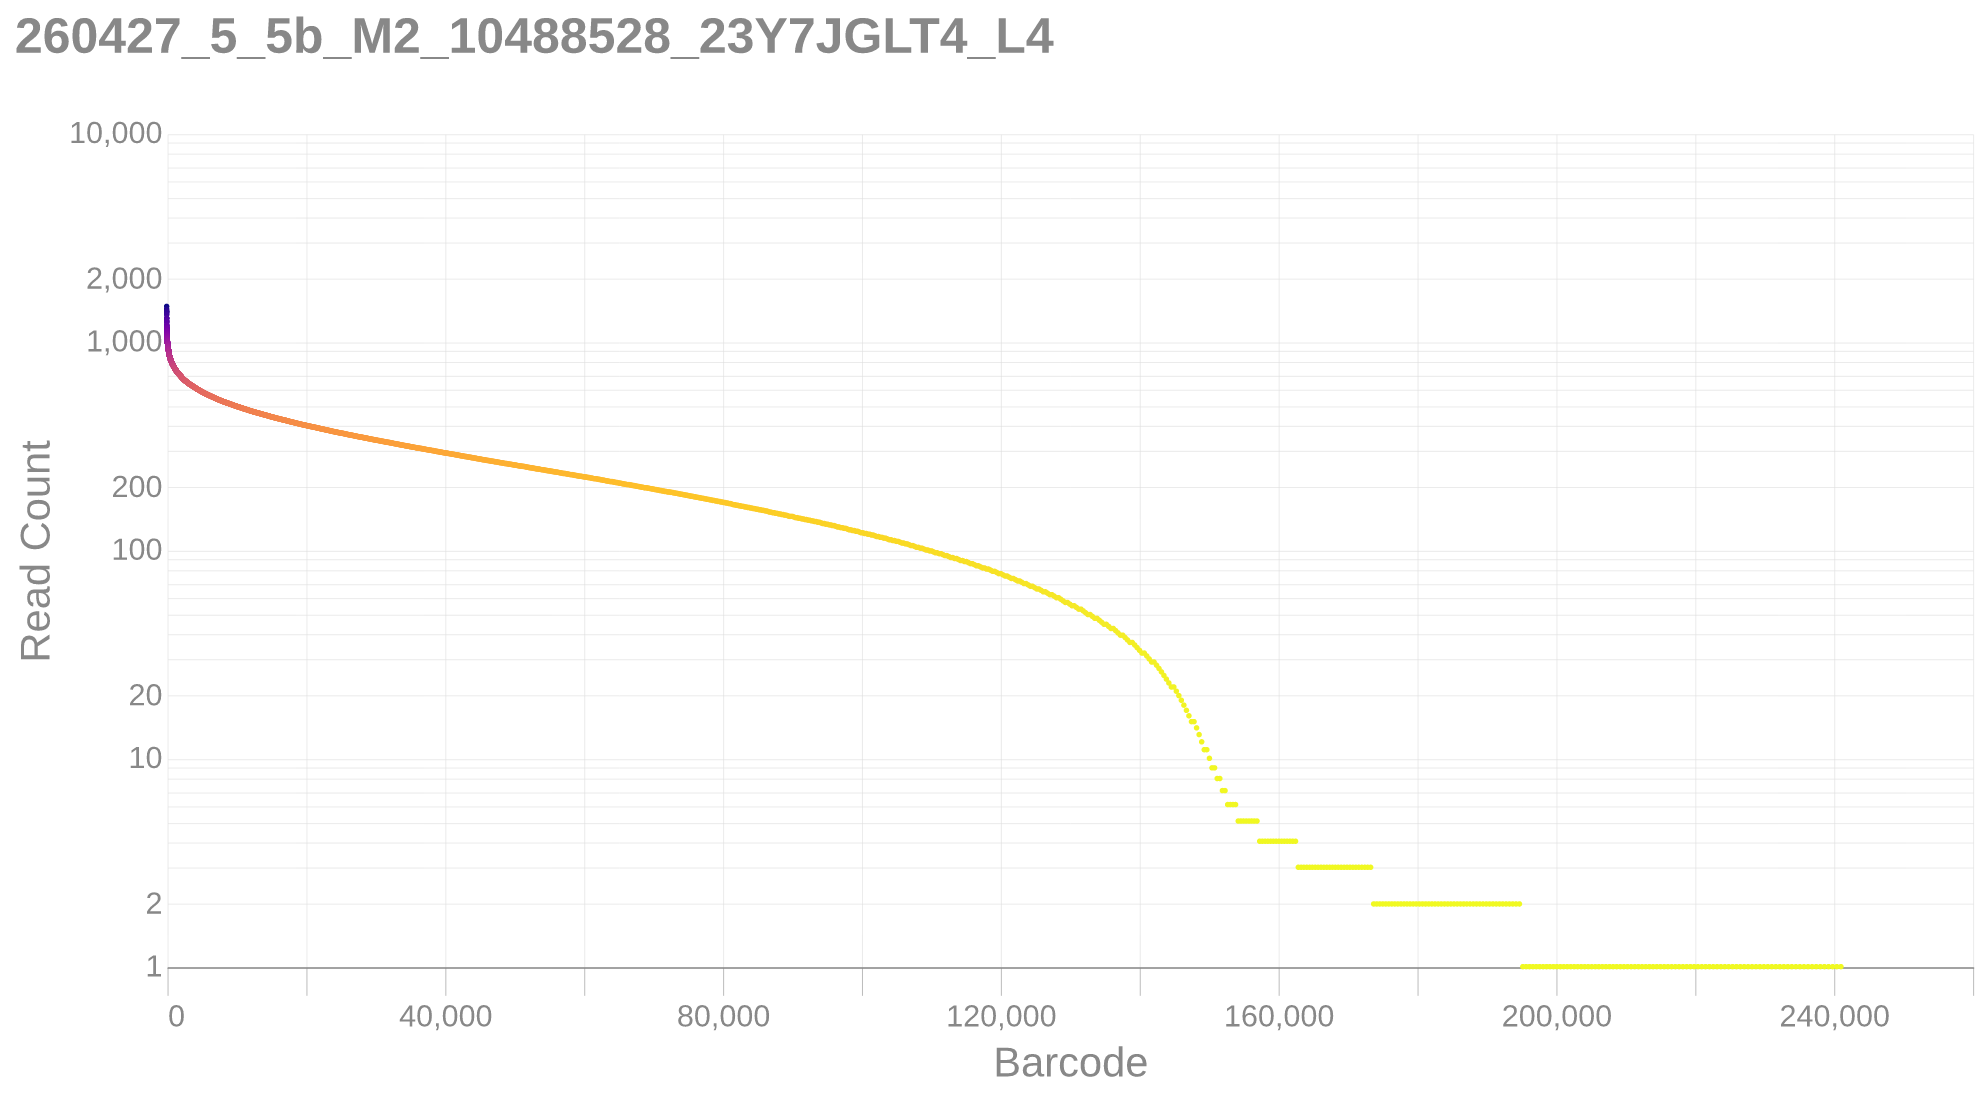
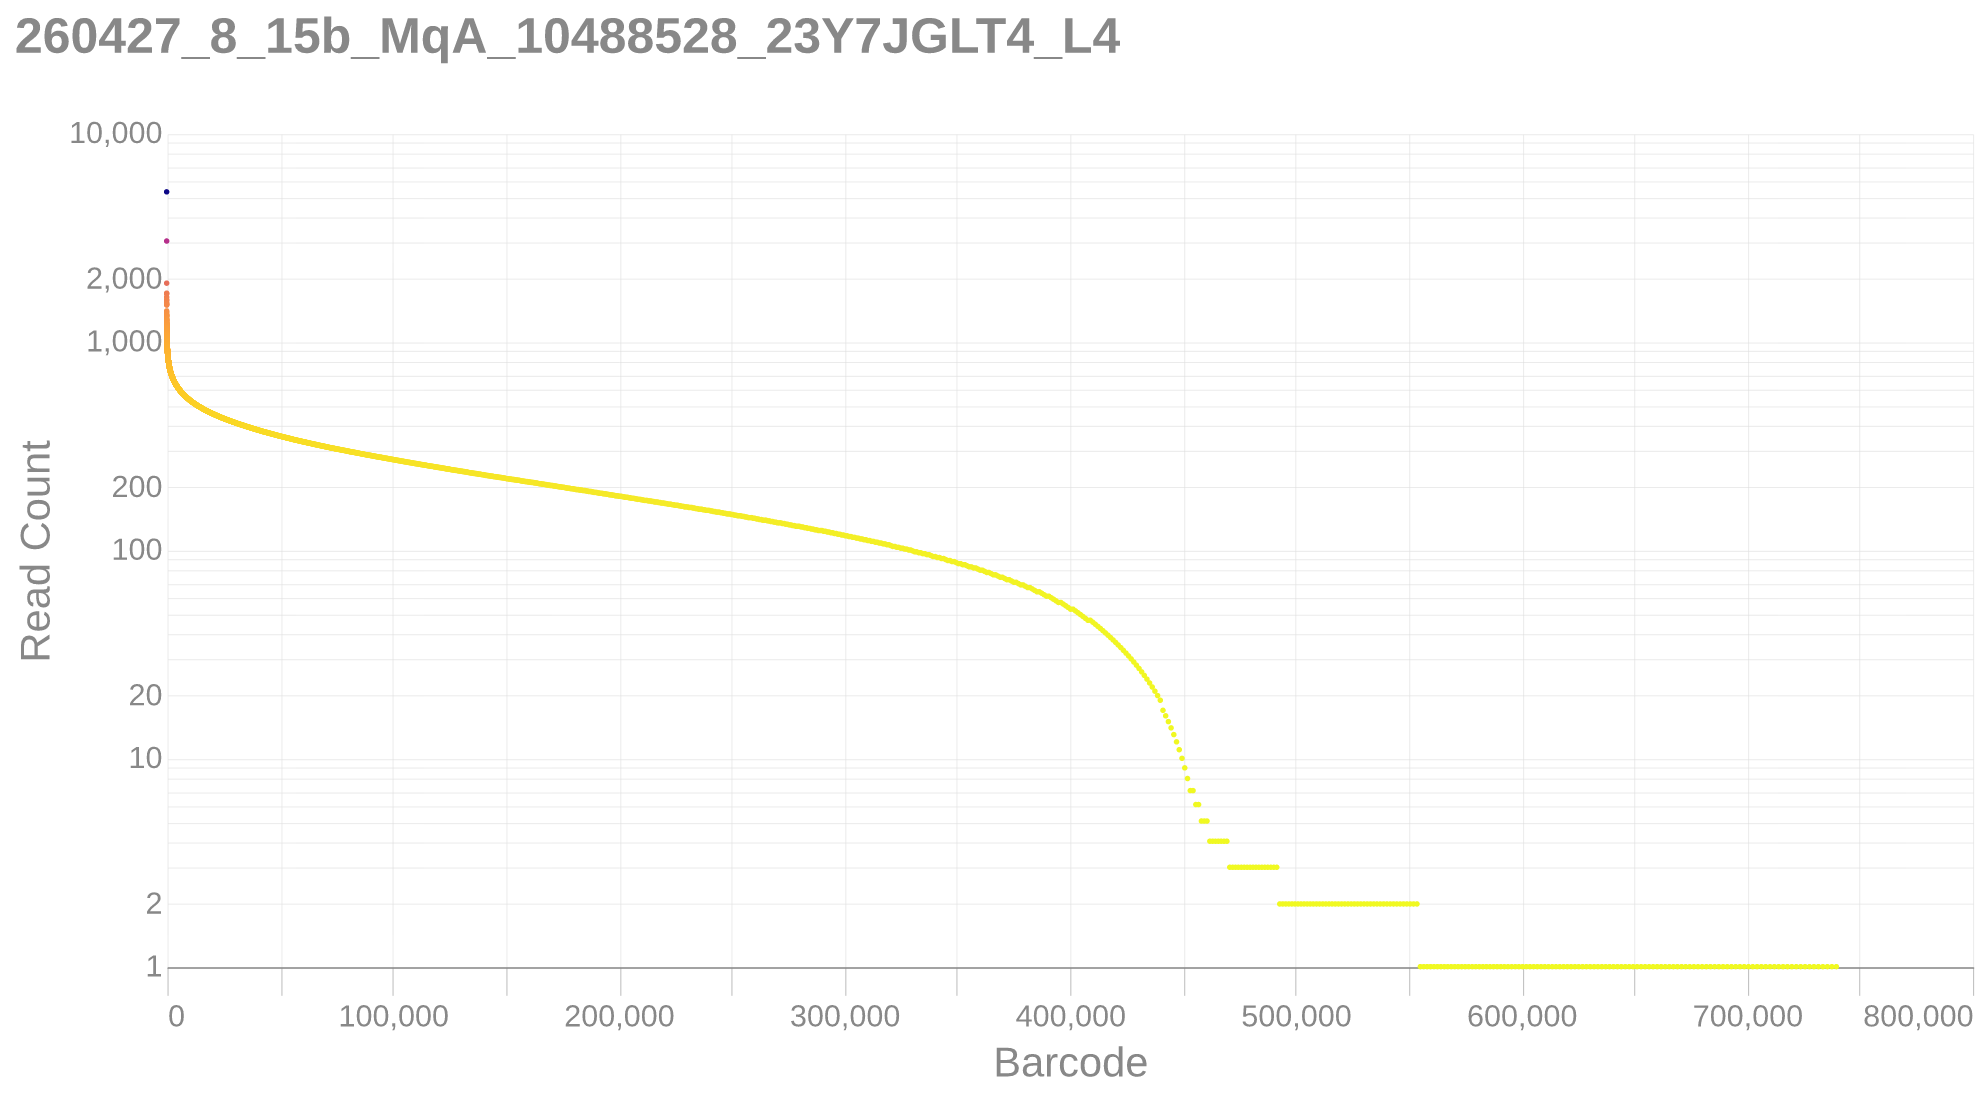

In [8]:
kneeplot_dir = os.path.join(os.path.dirname(indir), "kneeplots")
os.makedirs(kneeplot_dir, exist_ok=True)
for smp in d['Sample']:
    infile = os.path.join(indir, f"{smp}.bxcount")
    df = pl.read_csv(infile, separator = "\t", has_header = False, schema_overrides = [pl.String, pl.Int64])
    df.columns = ["bc", "count"]
    static_kneeplot(df["count"], smp, os.path.join(kneeplot_dir, f"{smp}.png"))

image_viewer("Sample", kneeplot_dir, "*.png", thing_to_select="sample")


In [9]:
[os.remove(i) for i in Path(kneeplot_dir).glob("*.png")]
os.removedirs(kneeplot_dir)
